In [1]:
import sys, os
sys.path.append('..')
import utils.io as io
from matplotlib import pyplot as plt
import numpy as np
import src.observables as obs
DATADIR = '../../data/iDMRG/'

In [2]:
# psi, results = io.load_mps_with_metadata('lastVpm_3.800_chi500.h5')
# psi, results = io.load_mps_with_metadata('ff_chi80.h5')
loadfile = os.path.join(DATADIR, "Vpm3.8cc/Vpm_3.800_chi500.h5")
psi, results = io.load_mps_with_metadata(loadfile)
print('Correlation length = ', psi.correlation_length2())
diags = results["diagnostics"]
diags.keys()

Correlation length =  106.40792819184962


dict_keys(['Delta_E', 'Delta_S', 'E', 'N_updates', 'S', 'max_E_trunc', 'max_S', 'max_chi', 'max_trunc_err', 'norm_err', 'sweep', 'time'])

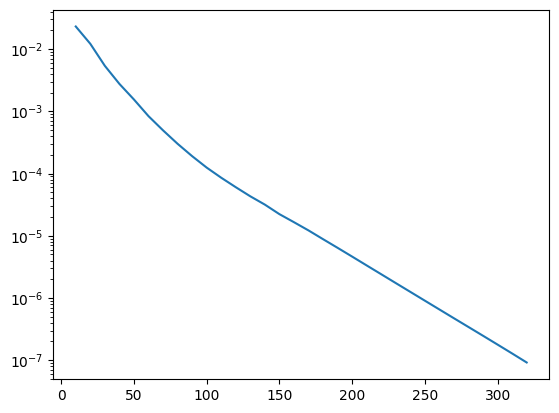

In [4]:
plt.plot(diags['sweep'], np.abs(diags['Delta_S']))
plt.yscale('log')

In [13]:
distrange = 100 #picked smaller than correlation length
chargecorr = obs.denoise_rolling(np.abs(obs.charge_corr(psi, distrange, connected=True)), window=4)
spinzcorr = obs.denoise_rolling(np.abs(obs.SzSz_corr(psi, distrange, connected=True)), window=4)
spinpmcorr = obs.denoise_rolling(np.abs(obs.SpSm_corr(psi, distrange)), window=4)
electroncorr = obs.denoise_rolling(np.abs(obs.electron_corr(psi, distrange, "tot")), window=4)

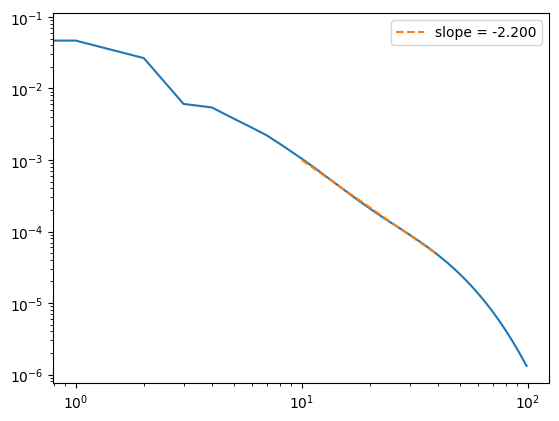

In [27]:
xvals = np.arange(distrange)
yvals = spinzcorr
plt.plot(xvals, yvals)
fitw = slice(10, 40)
m, logc = np.polyfit(np.log(xvals[fitw]), np.log(yvals[fitw]), 1)
plt.plot(xvals[fitw], np.exp(logc) * xvals[fitw]**m, ls='--', label=f'slope = {m:.3f}')
plt.yscale('log')
plt.xscale('log')
plt.legend()


In [19]:
psi.expectation_value('Sz')

array([-0.00024676, -0.00015593,  0.00024753,  0.00015516])